In [3]:
#Import the 3 Libraries 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Iris.csv')

# Displaying the first few rows
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
 #Total sample of the Data set.
total_ids = df['Id'].count()
print("Total Samples: ",total_ids)


# Returns an array of the unique species names.
species_list = df['Species'].unique().tolist()
Unique_class = len(species_list)
print(f"Unique Classes: {Unique_class} ({', '.join(species_list)})\n")

# Get the counts for each species.
counts = df['Species'].value_counts()

print("Distribution:")
for species, count in counts.items():
    print(f"{species}: {count} samples")

Total Samples:  150
Unique Classes: 3 (Iris-setosa, Iris-versicolor, Iris-virginica)

Distribution:
Iris-setosa: 50 samples
Iris-versicolor: 50 samples
Iris-virginica: 50 samples


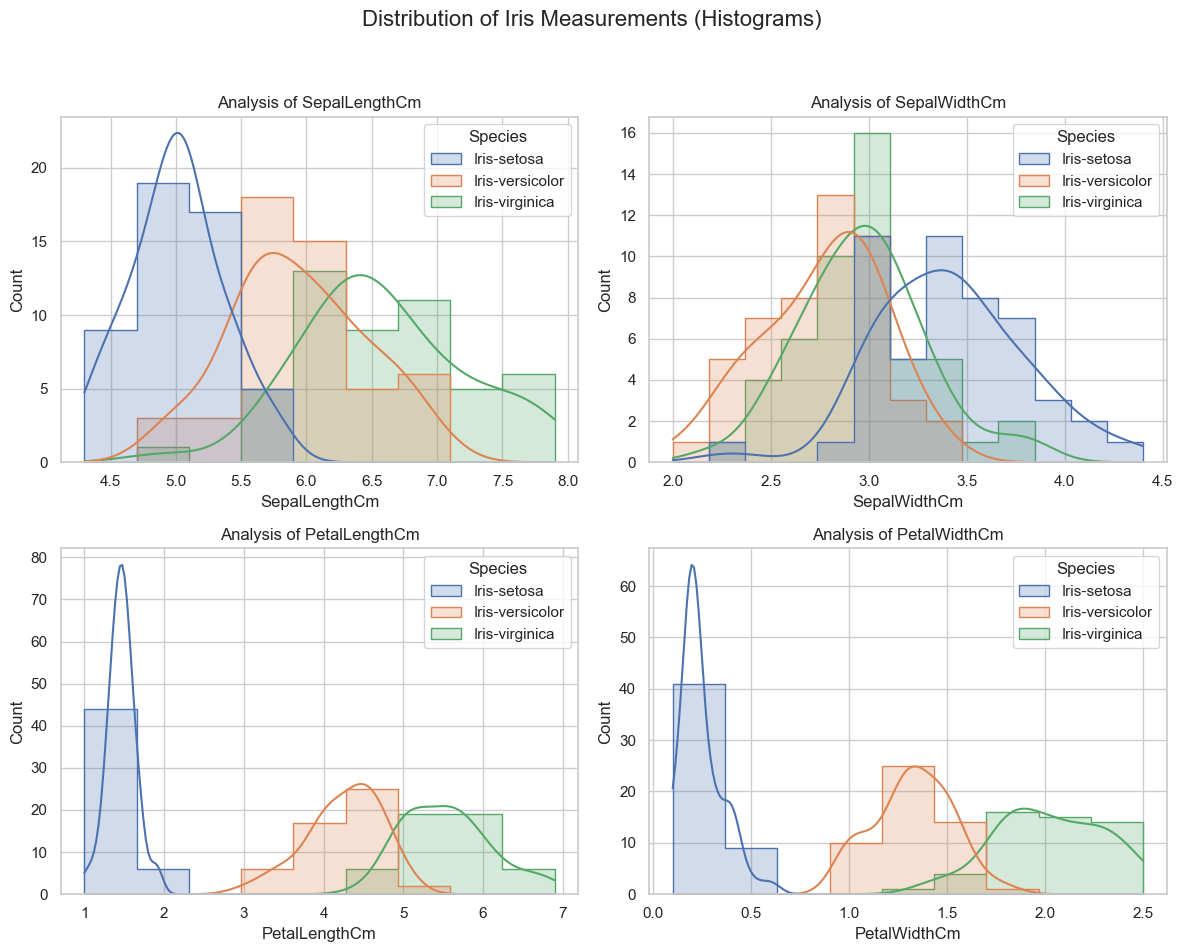

In [5]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Created a figure with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Iris Measurements (Histograms)', fontsize=16)

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for i, col in enumerate(features):
    sns.histplot(ax=axes[i//2, i%2], data=df, x=col, hue='Species', kde=True, element="step")
    axes[i//2, i%2].set_title(f'Analysis of {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

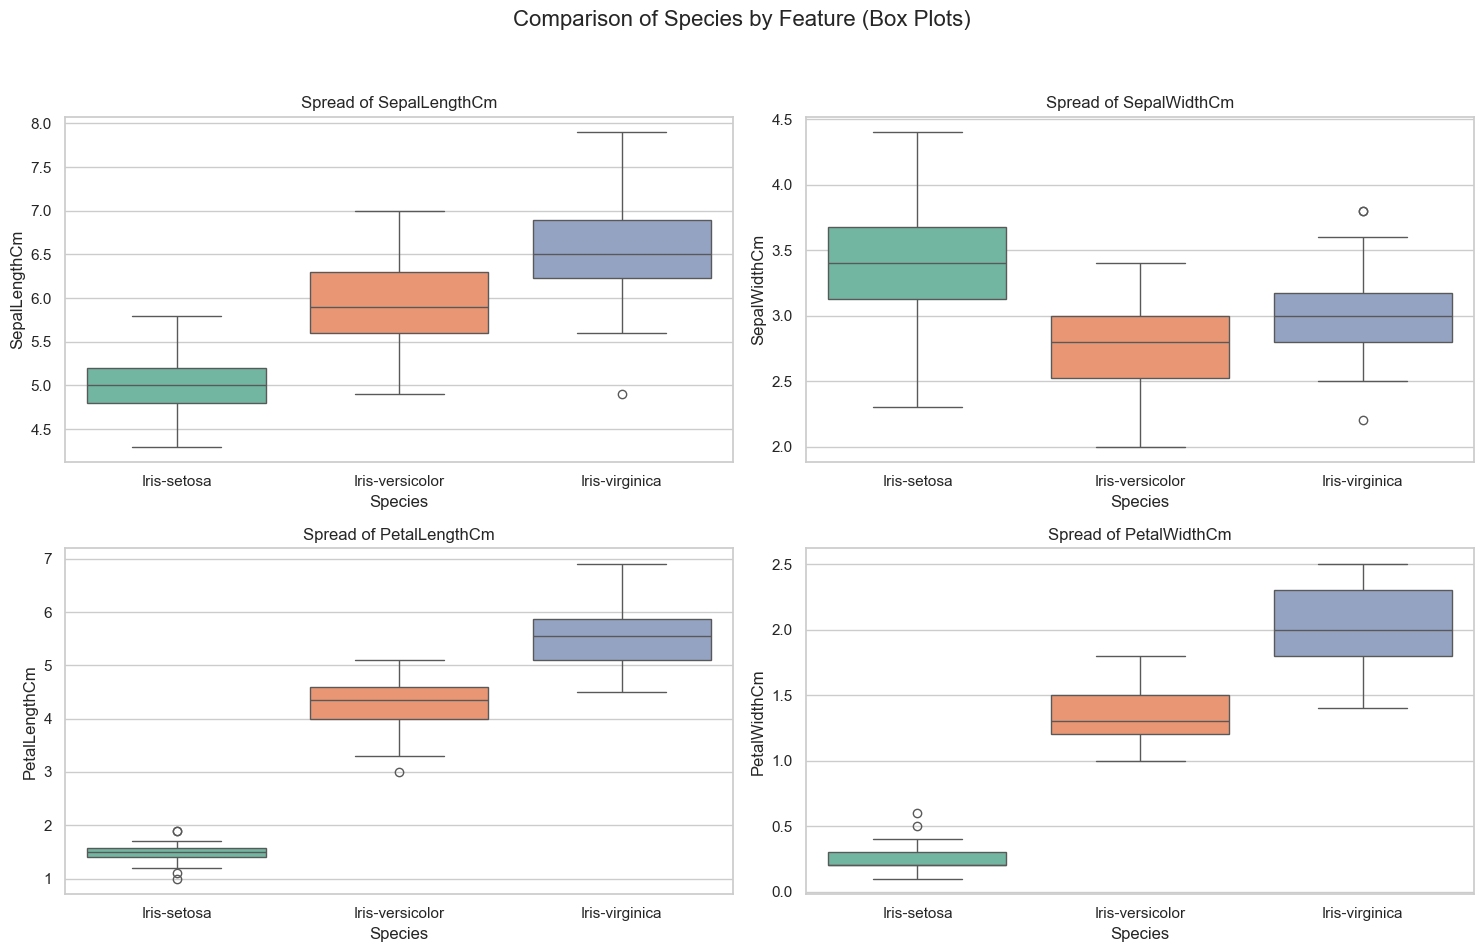

In [10]:
# Created a figure for Box Plots
plt.figure(figsize=(15, 10))
plt.suptitle('Comparison of Species by Feature (Box Plots)', fontsize=16)

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Species', y=col, data=df, hue='Species', palette="Set2", legend=False)
    plt.title(f'Spread of {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

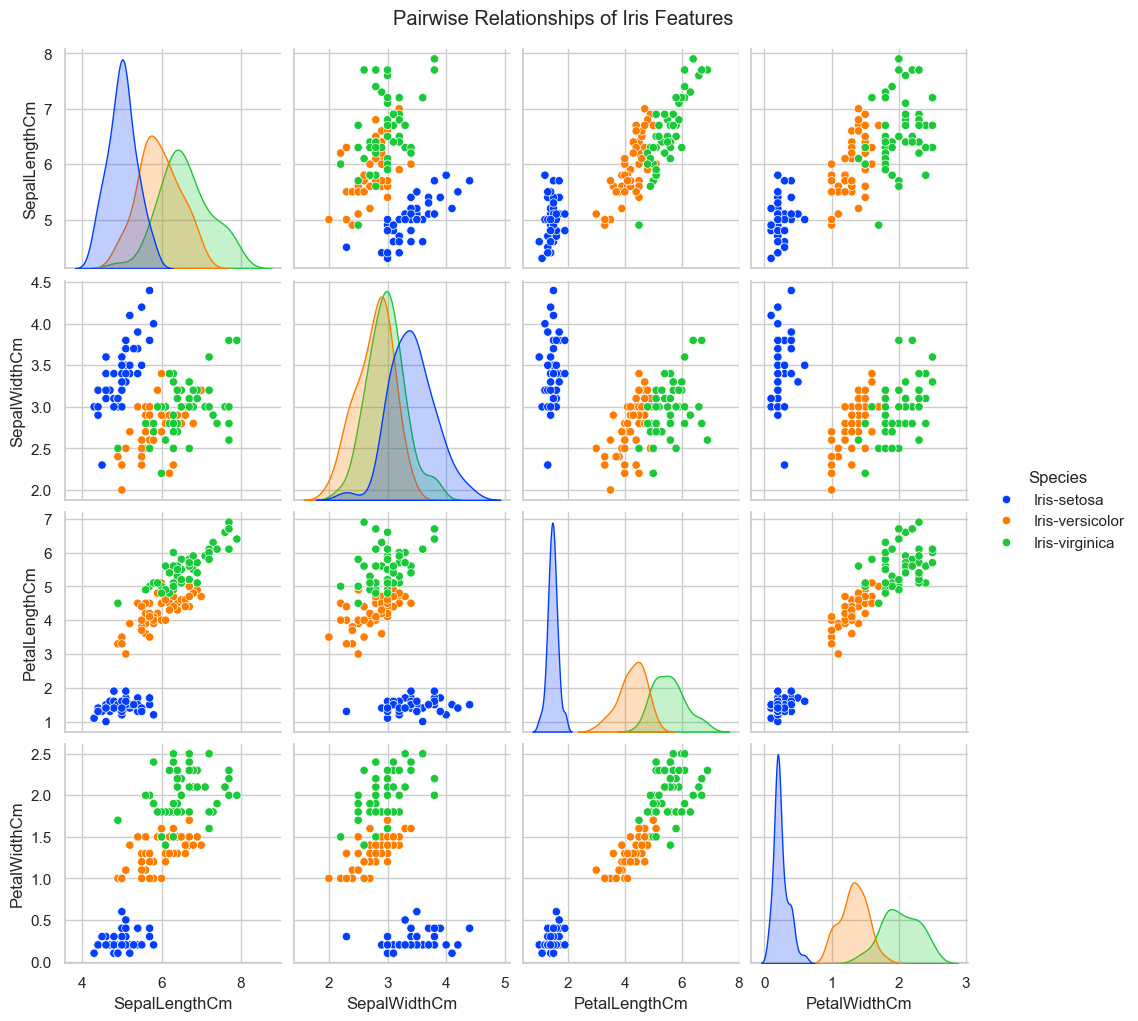

In [7]:
# Created the Pairplot
sns.pairplot(df.drop('Id', axis=1), hue='Species', palette='bright', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Iris Features', y=1.02) # y>1 keeps title above the plot
plt.show()

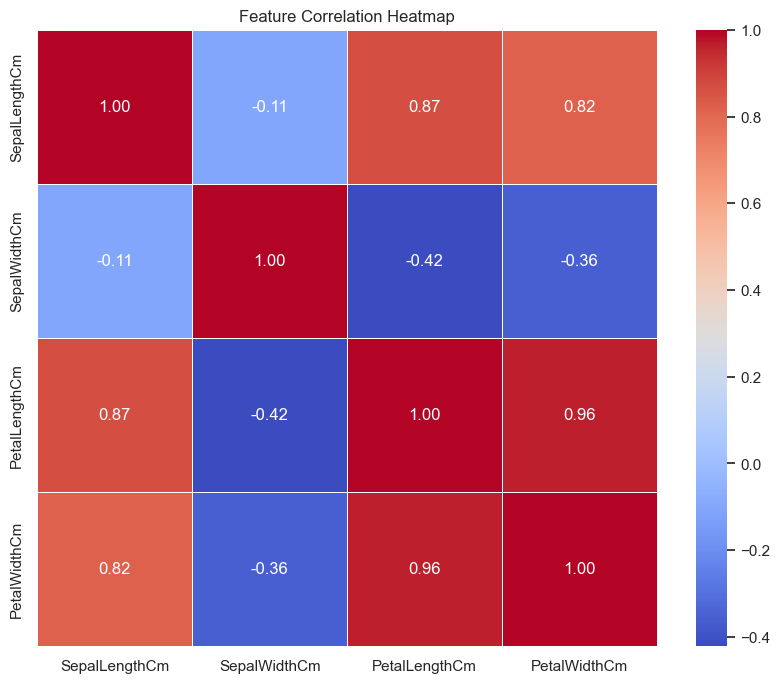

In [11]:
# Computed the correlation (dropping ID and the categorical Species column)
corr_matrix = df.drop(['Id', 'Species'], axis=1).corr()

# Displaying as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()